In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import warnings

# Sanity Checks para hacer el analisis del Infill

🔍 Iniciando Diagnóstico en: /home/lsilva/Github/ADST_Alexey_module_v7/parquet_sib_helio_17/

1. ESTADÍSTICA GLOBAL (Todo el dataset)
        Total_Muones  Total_Modulos_Encendidos  Eventos_Unicos
type                                                          
Denso   4.956567e+06                    864960            4986
Infill  3.498330e+06                    758097            4986

2. ANÁLISIS DE CORTE RADIAL: 400m - 600m
        Total_Muones  Total_Modulos  Promedio_Muones_Por_Modulo  \
type                                                              
Denso   4.775841e+06         807135                    5.917028   
Infill  5.358216e+05         123249                    4.347472   

        Std_Muones_Por_Modulo  
type                           
Denso                3.563036  
Infill               3.260144  

--- Estaciones por Evento (Multiplicidad) ---
Infill (Media): 24.84 módulos/evento
Denso  (Media): 162.43 módulos/evento


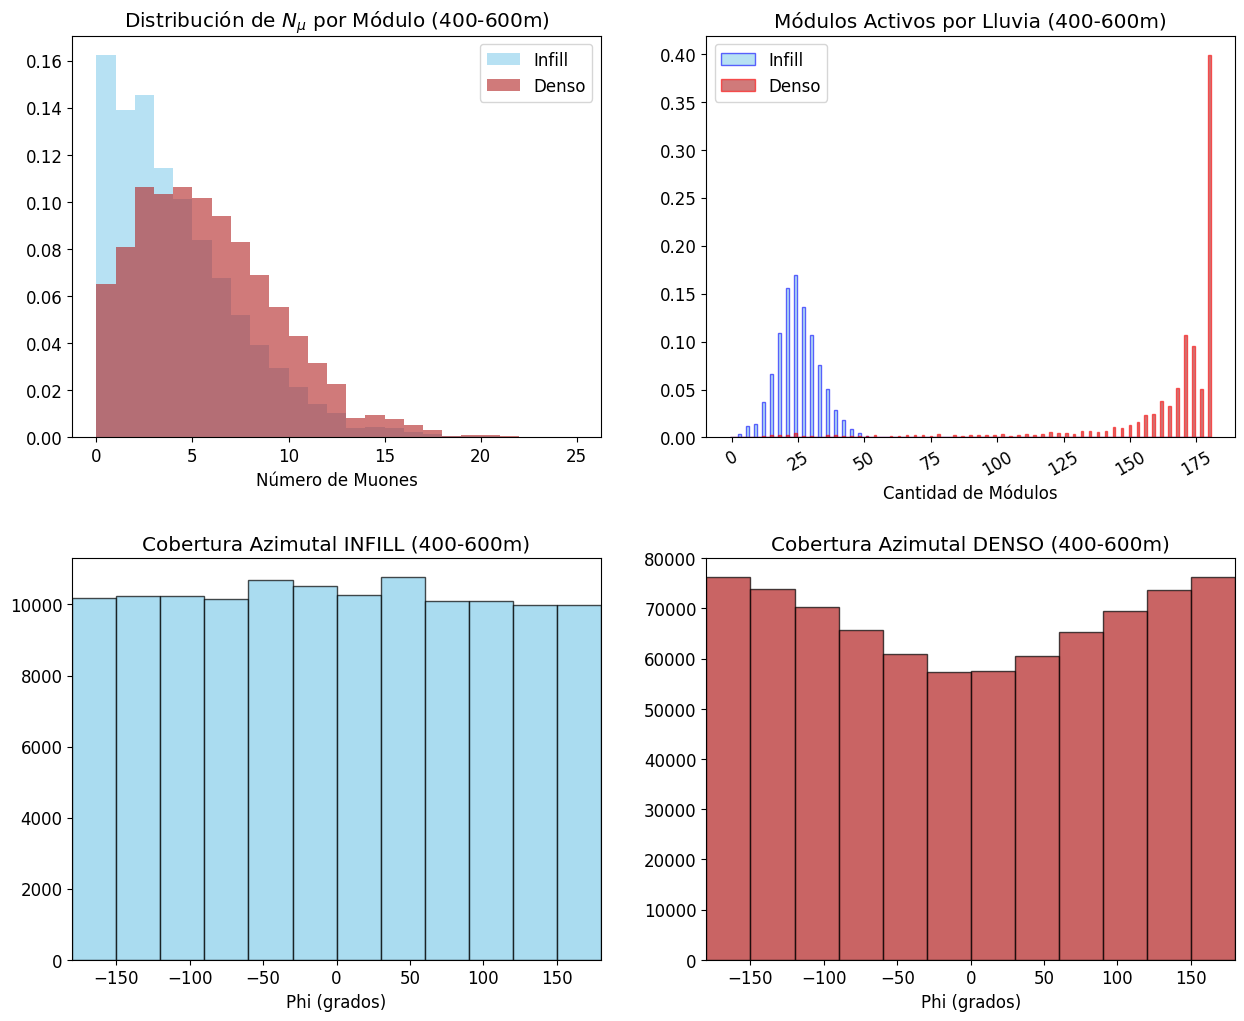

In [70]:
# --- CONFIGURACIÓN ---
# Tu carpeta
FOLDER_PATH = "/home/lsilva/Github/ADST_Alexey_module_v7/parquet_sib_helio_17/"

def diagnostico_infill_vs_denso(folder):
    print(f"🔍 Iniciando Diagnóstico en: {folder}")
    
    # 1. CARGA DE DATOS
    files = glob.glob(os.path.join(folder, "*.parquet"))
    if not files:
        print("❌ No se encontraron archivos.")
        return
    
    df_list = []
    # Cargamos solo las columnas necesarias para no explotar la RAM
    cols = ['event_id', 'counterId', 'nMuones_REC', 'r_core', 'phi_plane', 'module_status']
    
    for f in files:
        df_list.append(pd.read_parquet(f, columns=cols))
    
    df = pd.concat(df_list, ignore_index=True)
    
    # Filtro básico de calidad
    df = df[df['module_status'].isin(['candidate', 'rejected', 'saturated'])].copy()
    
    # --- 2. SEPARACIÓN DE GRUPOS ---
    # print(df['counterId'].unique())
    # Definimos las máscaras lógicas
    # Anillo Denso: 90000 <= ID < 100000
    mask_dense = (df['counterId'] >= 90000) & (df['counterId'] < 100000)
    # Infill: ID >= 100000 (Asumimos que el resto es Infill)
    mask_infill = (df['counterId'] >= 100000)
    
    df['type'] = np.where(mask_dense, 'Denso', 'Infill')
    
    print("\n" + "="*60)
    print("1. ESTADÍSTICA GLOBAL (Todo el dataset)")
    print("="*60)
    
    global_stats = df.groupby('type').agg(
        Total_Muones=('nMuones_REC', 'sum'),
        Total_Modulos_Encendidos=('counterId', 'count'), # Cada fila es un módulo
        Eventos_Unicos=('event_id', 'nunique')
    )
    print(global_stats)
    
    # --- 3. ANÁLISIS DEL CORTE RADIAL (400-600m) ---
    r_min, r_max = 400, 600
    print(f"\n" + "="*60)
    print(f"2. ANÁLISIS DE CORTE RADIAL: {r_min}m - {r_max}m")
    print("="*60)
    
    # Filtramos por radio
    cut = df[(df['r_core'] >= r_min) & (df['r_core'] < r_max)].copy()
    
    if cut.empty:
        print("⚠️ No hay datos en este rango radial.")
        return

    # Estadísticas del corte
    cut_stats = cut.groupby('type').agg(
        Total_Muones=('nMuones_REC', 'sum'),
        Total_Modulos=('counterId', 'count'),
        Promedio_Muones_Por_Modulo=('nMuones_REC', 'mean'),
        Std_Muones_Por_Modulo=('nMuones_REC', 'std')
    )
    print(cut_stats)
    
    # --- 4. FLUCTUACIONES LLUVIA A LLUVIA (Estaciones por Evento) ---
    # Esto es CRÍTICO: ¿Cuántas estaciones ve cada lluvia en este anillo?
    
    # Agrupamos por Evento y Tipo
    # Contamos cuántos módulos únicos (count) y sumamos muones (sum) por evento
    event_stats = cut.groupby(['event_id', 'type']).agg(
        modulos_per_event=('counterId', 'count'),
        muons_per_event=('nMuones_REC', 'sum')
    ).reset_index()
    
    # Separamos para plotear
    ev_infill = event_stats[event_stats['type'] == 'Infill']
    ev_dense = event_stats[event_stats['type'] == 'Denso']
    
    print("\n--- Estaciones por Evento (Multiplicidad) ---")
    print(f"Infill (Media): {ev_infill['modulos_per_event'].mean():.2f} módulos/evento")
    print(f"Denso  (Media): {ev_dense['modulos_per_event'].mean():.2f} módulos/evento")
    
    # --- PLOTS DE DIAGNÓSTICO ---
    fig, axs = plt.subplots(2, 2, figsize=(15, 12))
    plt.subplots_adjust(hspace=0.3)
    
    # Plot A: Histograma de Muones por Módulo (Fluctuación de señal)
    axs[0,0].hist(cut[cut['type']=='Infill']['nMuones_REC'], bins=25, range=(0,25), 
                  alpha=0.6, color='skyblue', label='Infill', density=True)
    axs[0,0].hist(cut[cut['type']=='Denso']['nMuones_REC'], bins=25, range=(0,25), 
                  alpha=0.6, color='firebrick', label='Denso', density=True)
    axs[0,0].set_title(rf"Distribución de $N_\mu$ por Módulo ({r_min}-{r_max}m)")
    axs[0,0].set_xlabel("Número de Muones")
    axs[0,0].legend()
    
    # Plot B: Histograma de Módulos por Evento (Multiplicidad)
    # ¿Cuántas estaciones se prenden en una lluvia típica?
    max_mods = max(ev_infill['modulos_per_event'].max(), ev_dense['modulos_per_event'].max())
    bins_ev = np.arange(0, max_mods + 2) - 0.5
    
    axs[0,1].hist(ev_infill['modulos_per_event'], bins=bins_ev, 
                  alpha=0.6, color='skyblue', label='Infill', density=True, edgecolor='blue')
    axs[0,1].hist(ev_dense['modulos_per_event'], bins=bins_ev, 
                  alpha=0.6, color='firebrick', label='Denso', density=True, edgecolor='red')
    axs[0,1].set_title(f"Módulos Activos por Lluvia ({r_min}-{r_max}m)")
    axs[0,1].set_xlabel("Cantidad de Módulos")
    axs[0,1].tick_params(axis='x', labelrotation=30)
    axs[0,1].legend()

    # Plot C: Cobertura en Phi (Infill)
    phi_deg_infill = np.rad2deg(cut[cut['type']=='Infill']['phi_plane'])
    phi_deg_infill = (phi_deg_infill + 180) % 360 - 180
    
    axs[1,0].hist(phi_deg_infill, bins=12, color='skyblue', edgecolor='k', alpha=0.7)
    axs[1,0].set_title(f"Cobertura Azimutal INFILL ({r_min}-{r_max}m)")
    axs[1,0].set_xlabel("Phi (grados)")
    axs[1,0].set_xlim(-180, 180)
    
    # Plot D: Cobertura en Phi (Denso)
    phi_deg_dense = np.rad2deg(cut[cut['type']=='Denso']['phi_plane'])
    phi_deg_dense = (phi_deg_dense + 180) % 360 - 180
    
    axs[1,1].hist(phi_deg_dense, bins=12, color='firebrick', edgecolor='k', alpha=0.7)
    axs[1,1].set_title(f"Cobertura Azimutal DENSO ({r_min}-{r_max}m)")
    axs[1,1].set_xlabel("Phi (grados)")
    axs[1,1].set_xlim(-180, 180)
    
    plt.show()

# --- EJECUTAR ---
diagnostico_infill_vs_denso(FOLDER_PATH)

📐 VERIFICACIÓN DE GEOMETRÍA (INFILL vs DENSO)


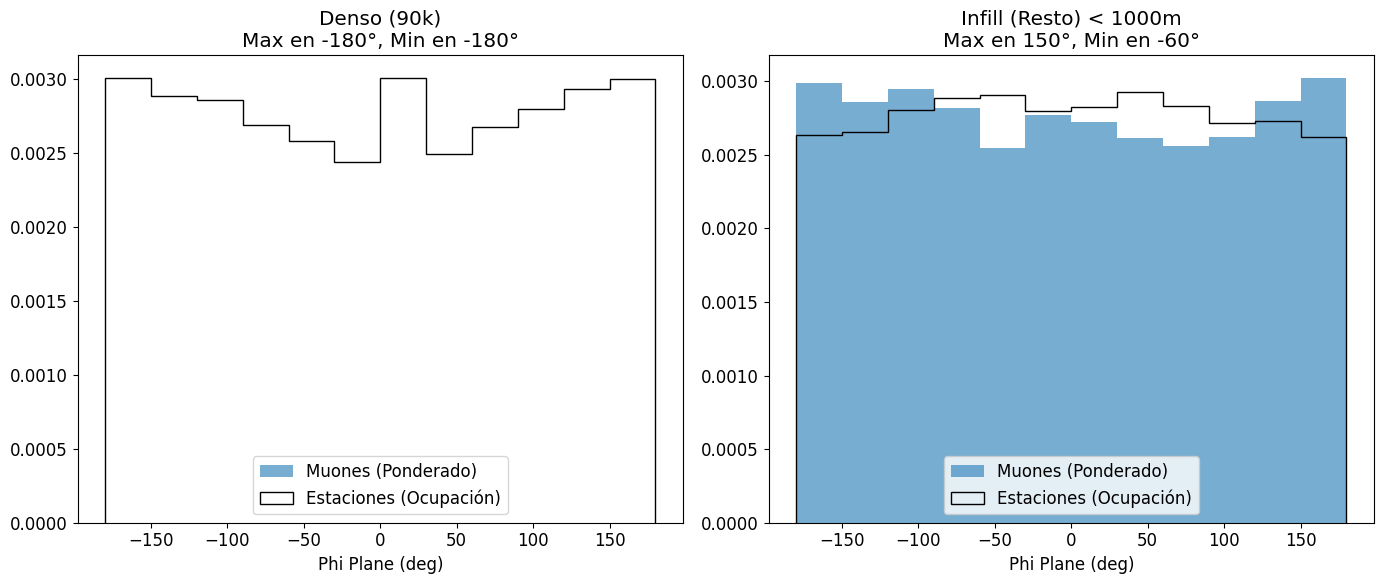

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

FOLDER = "/home/lsilva/Github/ADST_Alexey_module_v7/parquet_sib_helio_17/"

def check_geometry(folder):
    print("📐 VERIFICACIÓN DE GEOMETRÍA (INFILL vs DENSO)")
    files = glob.glob(os.path.join(folder, "*.parquet"))
    if not files: return
    
    # Cargar solo un par de archivos para que sea rápido
    df_list = []
    for f in files[:2]: 
        df_list.append(pd.read_parquet(f, columns=['counterId', 'nMuones_REC', 'r_core', 'phi_plane']))
    df = pd.concat(df_list)
    
    # Separar
    denso = df[(df['counterId'] >= 90000) & (df['counterId'] < 100000)]
    infill = df[~((df['counterId'] >= 90000) & (df['counterId'] < 100000)) & (df['r_core'] < 1000)]
    
    fig, axs = plt.subplots(1, 2, figsize=(14, 6))
    
    # PLOT POLAR: ¿Dónde caen los muones?
    # Deberíamos ver una modulación (más muones en un lado)
    
    for i, (data, label) in enumerate(zip([denso, infill], ['Denso (90k)', 'Infill (Resto) < 1000m'])):
        ax = axs[i]
        if data.empty: continue
        
        # Phi en grados
        phi = np.rad2deg(data['phi_plane'])
        phi = (phi + 180) % 360 - 180
        
        # Perfil de densidad
        # Usamos histograma ponderado por nMuones para ver dónde hay más señal
        counts, bins, _ = ax.hist(phi, bins=12, weights=data['nMuones_REC'], 
                                  alpha=0.6, label='Muones (Ponderado)', density=True)
        
        # Histograma de ocupación (dónde hay estaciones)
        ax.hist(phi, bins=12, histtype='step', color='k', label='Estaciones (Ocupación)', density=True)
        
        ax.set_title(f"{label}")
        ax.set_xlabel("Phi Plane (deg)")
        ax.legend()
        
        # Chequeo de Asimetría "a ojo"
        max_bin = bins[np.argmax(counts)]
        min_bin = bins[np.argmin(counts)]
        ax.set_title(f"{label}\nMax en {max_bin:.0f}°, Min en {min_bin:.0f}°")

    plt.tight_layout()
    plt.show()

check_geometry(FOLDER)

In [29]:
# Configuración visual
plt.rcParams.update({'font.size': 12, 'figure.figsize': (12, 6)})
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=pd.errors.SettingWithCopyWarning)

class RadialCutAnalyzer:
    def __init__(self, folder_path):
        """
        Herramienta para estudiar asimetría en cortes radiales específicos.
        Excluye automáticamente el Anillo Denso.
        """
        self.folder_path = folder_path
        self.df = pd.DataFrame()
        self.current_cut_data = None
        self.current_results = []
        
        # Definición de Bins de Theta (Estándar tesis)
        self.n_theta_bins = 6
        self.theta_labels = [] # Se llenan al cargar

    def load_data(self):
        """Carga parquets, limpia y calcula variables geométricas."""
        files = glob.glob(os.path.join(self.folder_path, "*.parquet"))
        if not files:
            print("❌ No se encontraron archivos .parquet")
            return

        print(f"📂 Cargando {len(files)} archivos...")
        df_list = [pd.read_parquet(f) for f in files]
        self.df = pd.concat(df_list, ignore_index=True)
        
        # 1. EXCLUIR ANILLO DENSO (90k)
        # Nos quedamos solo con Infill/Standard (IDs != 90xxx)
        self.df = self.df[~((self.df['counterId'] >= 90000) & (self.df['counterId'] < 100000))].copy()
        
        # 2. FILTROS BÁSICOS
        self.df = self.df[
            (self.df['nMuones_REC'].notna()) &
            (self.df['r_core'].notna())
        ].copy()

        # 3. GEOMETRÍA
        # Theta
        self.df['s2_theta'] = np.sin(np.deg2rad(self.df['theta_REC']))**2
        
        # Phi (Centrado en 0)
        phi_deg = np.rad2deg(self.df['phi_plane'])
        self.df['phi_deg'] = (phi_deg + 180) % 360 - 180
        
        # 4. BINNING EN THETA (Fijo para comparar)
        theta_max = min(65, self.df['theta_REC'].max())
        s2_bins = np.linspace(
            np.sin(np.deg2rad(self.df['theta_REC'].min()))**2,
            np.sin(np.deg2rad(theta_max))**2,
            self.n_theta_bins + 1
        )
        self.df['theta_bin'] = pd.cut(self.df['s2_theta'], bins=s2_bins, labels=False, include_lowest=True)
        
        # Guardar etiquetas para plots
        edges = np.rad2deg(np.arcsin(np.sqrt(s2_bins)))
        self.theta_labels = [f"{edges[i]:.1f}-{edges[i+1]:.1f}°" for i in range(len(edges)-1)]
        
        print(f"✅ Datos listos: {len(self.df)} módulos (Sin Anillo Denso).")

    def _fit_func(self, phi, A1):
        # Fase fija en 0, Offset fijo en 1
        return 1.0 * (1 + A1 * np.cos(np.deg2rad(phi)))

    def analizar_corte(self, r_min, r_max):
        """
        Analiza un anillo específico entre r_min y r_max.
        """
        print(f"\n🔍 Analizando Corte Radial: {r_min} m < r < {r_max} m")
        
        # 1. Filtrar por Radio
        self.current_cut_data = self.df[
            (self.df['r_core'] >= r_min) & 
            (self.df['r_core'] < r_max)
        ].copy()
        
        if self.current_cut_data.empty:
            print("⚠️ No hay datos en este rango radial.")
            return

        print(f"   -> Módulos encontrados: {len(self.current_cut_data)}")
        
        # 2. Ajuste por Bin de Theta
        phi_bins = np.linspace(-180, 180, 13)
        phi_centers = (phi_bins[:-1] + phi_bins[1:]) / 2
        
        results = []
        
        # Preparamos plot de validación (6 subplots)
        fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=True)
        fig.suptitle(f"Ajustes de Modulación Azimutal (Radio {r_min}-{r_max} m)", fontsize=16)
        axes = axes.flatten()

        for i in range(self.n_theta_bins):
            ax = axes[i]
            subset = self.current_cut_data[self.current_cut_data['theta_bin'] == i]
            
            if len(subset) < 50:
                ax.text(0.5, 0.5, "Poca Estadística", ha='center')
                continue
                
            # Perfil
            subset['phi_hist'] = pd.cut(subset['phi_deg'], bins=phi_bins)
            stats = subset.groupby('phi_hist', observed=True)['nMuones_REC'].agg(['mean', 'std', 'count'])
            
            norm = stats['mean'].mean()
            y = stats['mean'] / norm
            yerr = (stats['std'] / np.sqrt(stats['count'])) / norm
            
            # Plot Datos
            ax.errorbar(phi_centers, y, yerr=yerr, fmt='o', color='navy', label='Datos')
            
            # Fit
            try:
                popt, pcov = curve_fit(self._fit_func, phi_centers, y, p0=[0.05], sigma=yerr)
                A1 = popt[0]
                A1_err = np.sqrt(pcov[0,0])
                
                # Plot Fit
                x_fit = np.linspace(-180, 180, 100)
                ax.plot(x_fit, self._fit_func(x_fit, *popt), 'r--', label=f'A1={A1:.3f}')
                
                results.append({'theta_bin': i, 'A1': A1, 'A1_err': A1_err})
            except:
                ax.text(0, 1.05, "Fit Falló")
            
            ax.set_title(self.theta_labels[i])
            ax.grid(True, alpha=0.3)
            if i == 0: ax.legend(fontsize=8)

        plt.tight_layout()
        plt.show()
        
        self.current_results = pd.DataFrame(results)
        
        # 3. Plot Resumen A1 vs Theta para este radio
        if not self.current_results.empty:
            self.plot_summary(r_min, r_max)

    def plot_summary(self, r_min, r_max):
        """Muestra A1 vs Theta para el corte actual."""
        fig, ax = plt.subplots(figsize=(8, 5))
        
        res = self.current_results
        ax.errorbar(res['theta_bin'], res['A1'], yerr=res['A1_err'], 
                    fmt='o-', color='darkgreen', capsize=4, label='UMD REC')
        
        ax.set_title(f"Amplitud de Asimetría vs Theta\nCorte Radial: {r_min} - {r_max} m")
        ax.set_xlabel("Bin de Theta")
        ax.set_ylabel(r"$A_1$")
        ax.set_xticks(range(self.n_theta_bins))
        ax.set_xticklabels(self.theta_labels)
        ax.axhline(0, color='gray', linestyle='--')
        ax.grid(True, alpha=0.5)
        
        plt.show()

📂 Cargando 20 archivos...
✅ Datos Infill cargados: 481237 módulos activos.

🔍 ANÁLISIS RADIO: 400 - 800 m
   -> Módulos: 238563
   -> Promedio de Muones por módulo: 3.43


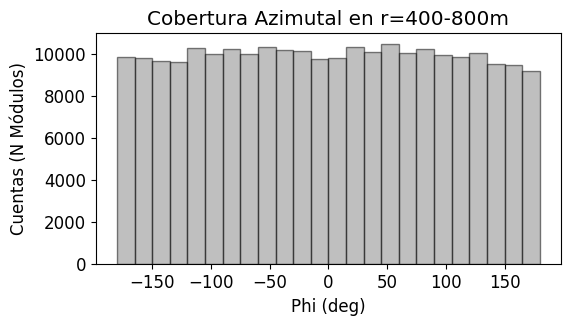

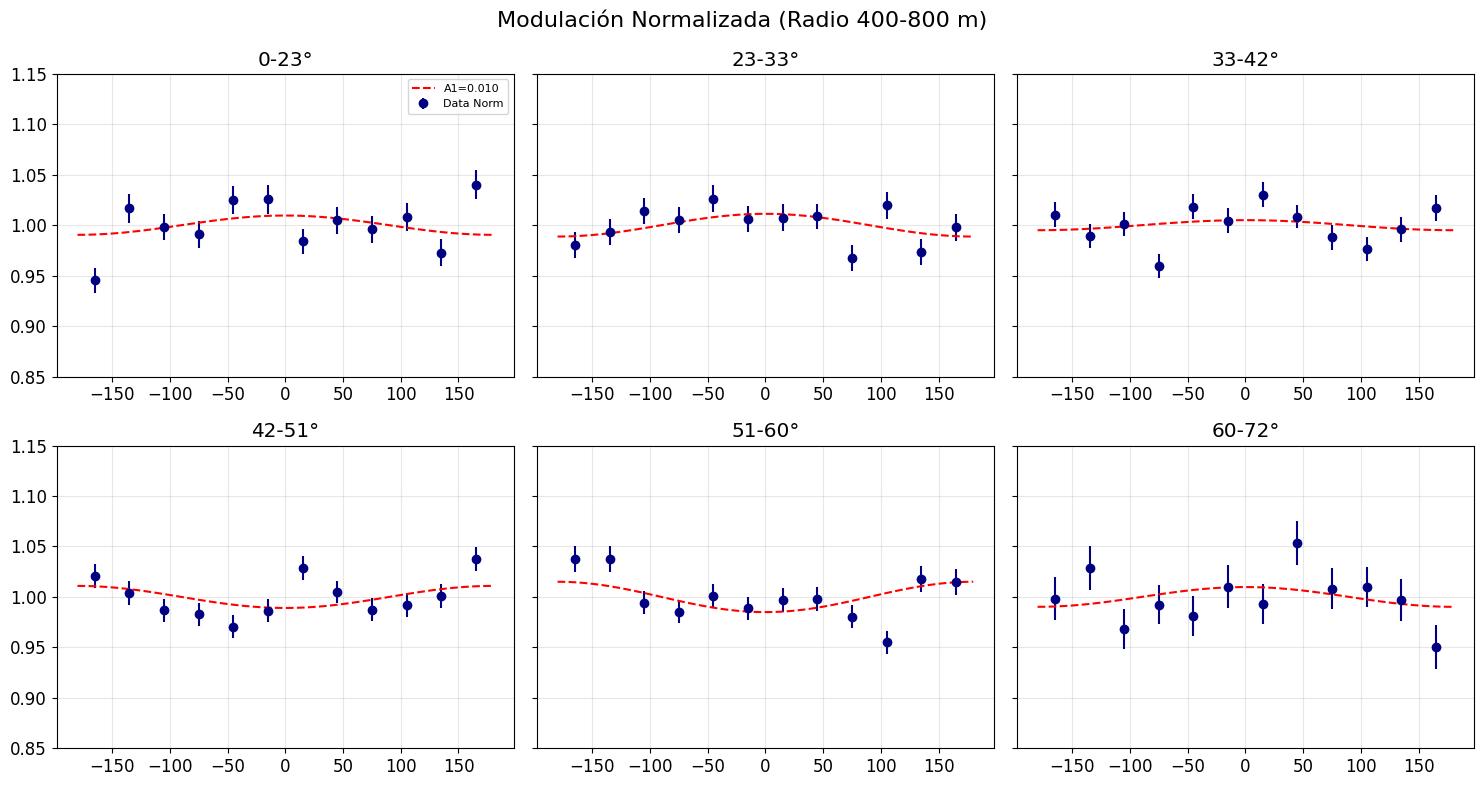

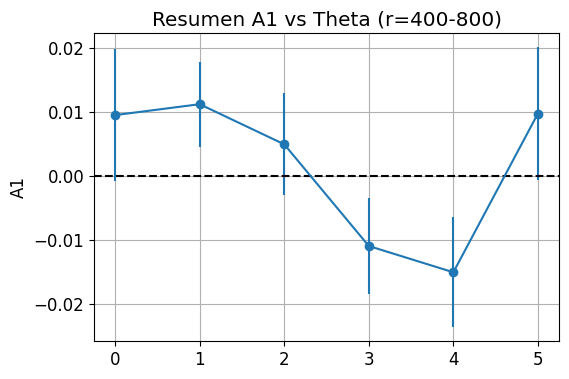

In [72]:
# --- EJEMPLO DE USO ---
# 1. Definí tu carpeta
folder = "/home/lsilva/Github/ADST_Alexey_module_v7/parquet_sib_helio_17/" # Poné la ruta real acá

# 2. Instanciá y cargá
analyzer = RadialCutAnalyzer(folder)
analyzer.load_data()

# 3. ¡Jugá con los cortes! 
analyzer.analizar_corte(r_min=400, r_max=800)   # Cerca
# analyzer.analizar_corte(r_min=600, r_max=1000)  # Medio
# analyzer.analizar_corte(r_min=1000, r_max=2000) # Lejos

In [87]:
class RadialCutAnalyzer:
    def __init__(self, folder_path):
        self.folder_path = folder_path
        self.df = pd.DataFrame()
        self.current_cut_data = None
        
        # Usamos 6 bins de Theta estándar
        self.n_theta_bins = 10
        self.theta_labels = [] 

    def load_data(self):
        """Carga y Pre-procesa."""
        files = glob.glob(os.path.join(self.folder_path, "*.parquet"))
        if not files:
            print("❌ No hay parquets.")
            return

        print(f"📂 Cargando {len(files)} archivos...")
        df_list = [pd.read_parquet(f) for f in files]
        self.df = pd.concat(df_list, ignore_index=True)
        
        # 1. EXCLUIR ANILLO DENSO (Nos quedamos con el Infill)
        self.df = self.df[~((self.df['counterId'] >= 90000) & (self.df['counterId'] < 100000))].copy()
        
        # 2. FILTROS
        self.df = self.df[
            (self.df['nMuones_REC'].notna()) & (self.df['nMuones_REC'] > 0) & # Solo módulos con señal
            (self.df['r_core'].notna())
        ].copy()

        # 3. GEOMETRÍA
        self.df['s2_theta'] = np.sin(np.deg2rad(self.df['theta_REC']))**2
        phi_deg = np.rad2deg(self.df['phi_plane'])
        self.df['phi_deg'] = (phi_deg + 180) % 360 - 180
        
        # 4. BINNING THETA
        theta_max = min(65, self.df['theta_REC'].max())
        s2_bins = np.linspace(np.sin(np.deg2rad(0)), np.sin(np.deg2rad(theta_max)), self.n_theta_bins + 1)
        self.df['theta_bin'] = pd.cut(self.df['s2_theta'], bins=s2_bins, labels=False)
        
        edges = np.rad2deg(np.arcsin(np.sqrt(s2_bins)))
        self.theta_labels = [f"{edges[i]:.0f}-{edges[i+1]:.0f}°" for i in range(len(edges)-1)]
        
        print(f"✅ Datos Infill cargados: {len(self.df)} módulos activos.")

    def _fit_func(self, phi, A1):
        return 1.0 * (1 + A1 * np.cos(np.deg2rad(phi)))

    def analizar_corte(self, r_min, r_max):
        print(f"\n🔍 ANÁLISIS RADIO: {r_min} - {r_max} m")
        
        # Filtrar por radio
        subset = self.df[(self.df['r_core'] >= r_min) & (self.df['r_core'] < r_max)].copy()
        
        if subset.empty:
            print("⚠️ Sin datos en este rango.")
            return

        # --- DIAGNÓSTICO 1: ESTADÍSTICA ---
        mean_mu = subset['nMuones_REC'].mean()
        print(f"   -> Módulos: {len(subset)}")
        print(f"   -> Promedio de Muones por módulo: {mean_mu:.2f}")
        
        if mean_mu < 1.0:
            print("⚠️ ALERTA: Señal muy baja (<1 muón/módulo). Poisson domina todo.")

        # --- DIAGNÓSTICO 2: COBERTURA PHI (Aceptación) ---
        # Verificamos si la grilla del Infill nos da cobertura uniforme
        plt.figure(figsize=(6, 3))
        plt.hist(subset['phi_deg'], bins=24, color='gray', alpha=0.5, edgecolor='k')
        plt.title(f"Cobertura Azimutal en r={r_min}-{r_max}m")
        plt.xlabel("Phi (deg)")
        plt.ylabel("Cuentas (N Módulos)")
        plt.show()
        # Si este histograma tiene "huecos" o picos feos, ahí está tu problema.

        # --- ANÁLISIS DE ASIMETRÍA ---
        # Bins de Phi
        phi_bins = np.linspace(-180, 180, 13)
        phi_centers = (phi_bins[:-1] + phi_bins[1:]) / 2
        
        fig, axes = plt.subplots(5, 2, figsize=(15, 15), sharey=True)
        fig.suptitle(f"Modulación Normalizada (Radio {r_min}-{r_max} m)", fontsize=16)
        axes = axes.flatten()
        
        results_list = []

        for i in range(self.n_theta_bins):
            ax = axes[i]
            # Datos del bin angular
            df_bin = subset[subset['theta_bin'] == i].copy()
            
            if len(df_bin) < 100: continue

            # --- NORMALIZACIÓN CRÍTICA ---
            # Para evitar que una lluvia gigante domine el promedio, 
            # dividimos cada nMuon por el promedio global de este rango radial
            # (Una normalización mejor sería event-by-event, pero esto ayuda)
            global_avg = df_bin['nMuones_REC'].mean()
            df_bin['norm_signal'] = df_bin['nMuones_REC'] / global_avg

            # Agrupar por Phi
            df_bin['phi_bin_idx'] = pd.cut(df_bin['phi_deg'], bins=phi_bins)
            stats = df_bin.groupby('phi_bin_idx', observed=True)['norm_signal'].agg(['mean', 'std', 'count'])
            
            # Datos para plotear
            # Ya normalizamos antes, así que 'mean' debería estar cerca de 1.0
            y = stats['mean']
            # Error del promedio (SEM)
            yerr = stats['std'] / np.sqrt(stats['count'])
            
            # Plot
            ax.errorbar(phi_centers, y, yerr=yerr, fmt='o', color='navy', label='Data Norm')
            
            # Fit
            try:
                # p0=[0.05] -> semilla inicial 5% de asimetría
                popt, pcov = curve_fit(self._fit_func, phi_centers, y, p0=[0.05], sigma=yerr)
                A1 = popt[0]
                A1_err = np.sqrt(pcov[0,0])
                
                x_fit = np.linspace(-180, 180, 100)
                ax.plot(x_fit, self._fit_func(x_fit, *popt), 'r--', label=f'A1={A1:.3f}')
                
                results_list.append({'theta': i, 'val': A1, 'err': A1_err})
            except:
                ax.text(0, 1, "Fit Fail")

            ax.set_title(self.theta_labels[i])
            ax.grid(True, alpha=0.3)
            ax.set_ylim(0.85, 1.15) # Zoom en el 1.0
            if i==0: ax.legend(fontsize=8)

        plt.tight_layout()
        plt.show()
        
        # Resumen
        if results_list:
            res_df = pd.DataFrame(results_list)
            plt.figure(figsize=(6, 4))
            plt.errorbar(res_df['theta'], res_df['val'], yerr=res_df['err'], fmt='o-')
            plt.title(f"Resumen A1 vs Theta (r={r_min}-{r_max})")
            plt.ylabel("A1")
            plt.grid(True)
            plt.axhline(0, color='k', ls='--')
            plt.show()

📂 Cargando 20 archivos...
✅ Datos Infill cargados: 481237 módulos activos.

🔍 ANÁLISIS RADIO: 0 - 200 m
   -> Módulos: 25757
   -> Promedio de Muones por módulo: 58.21


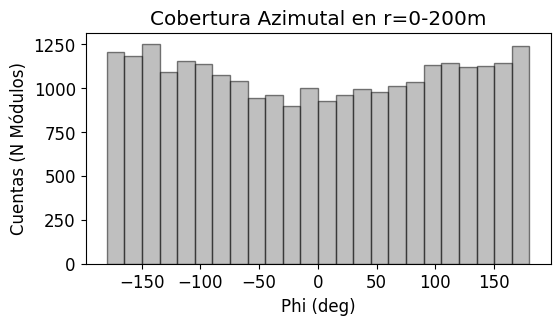

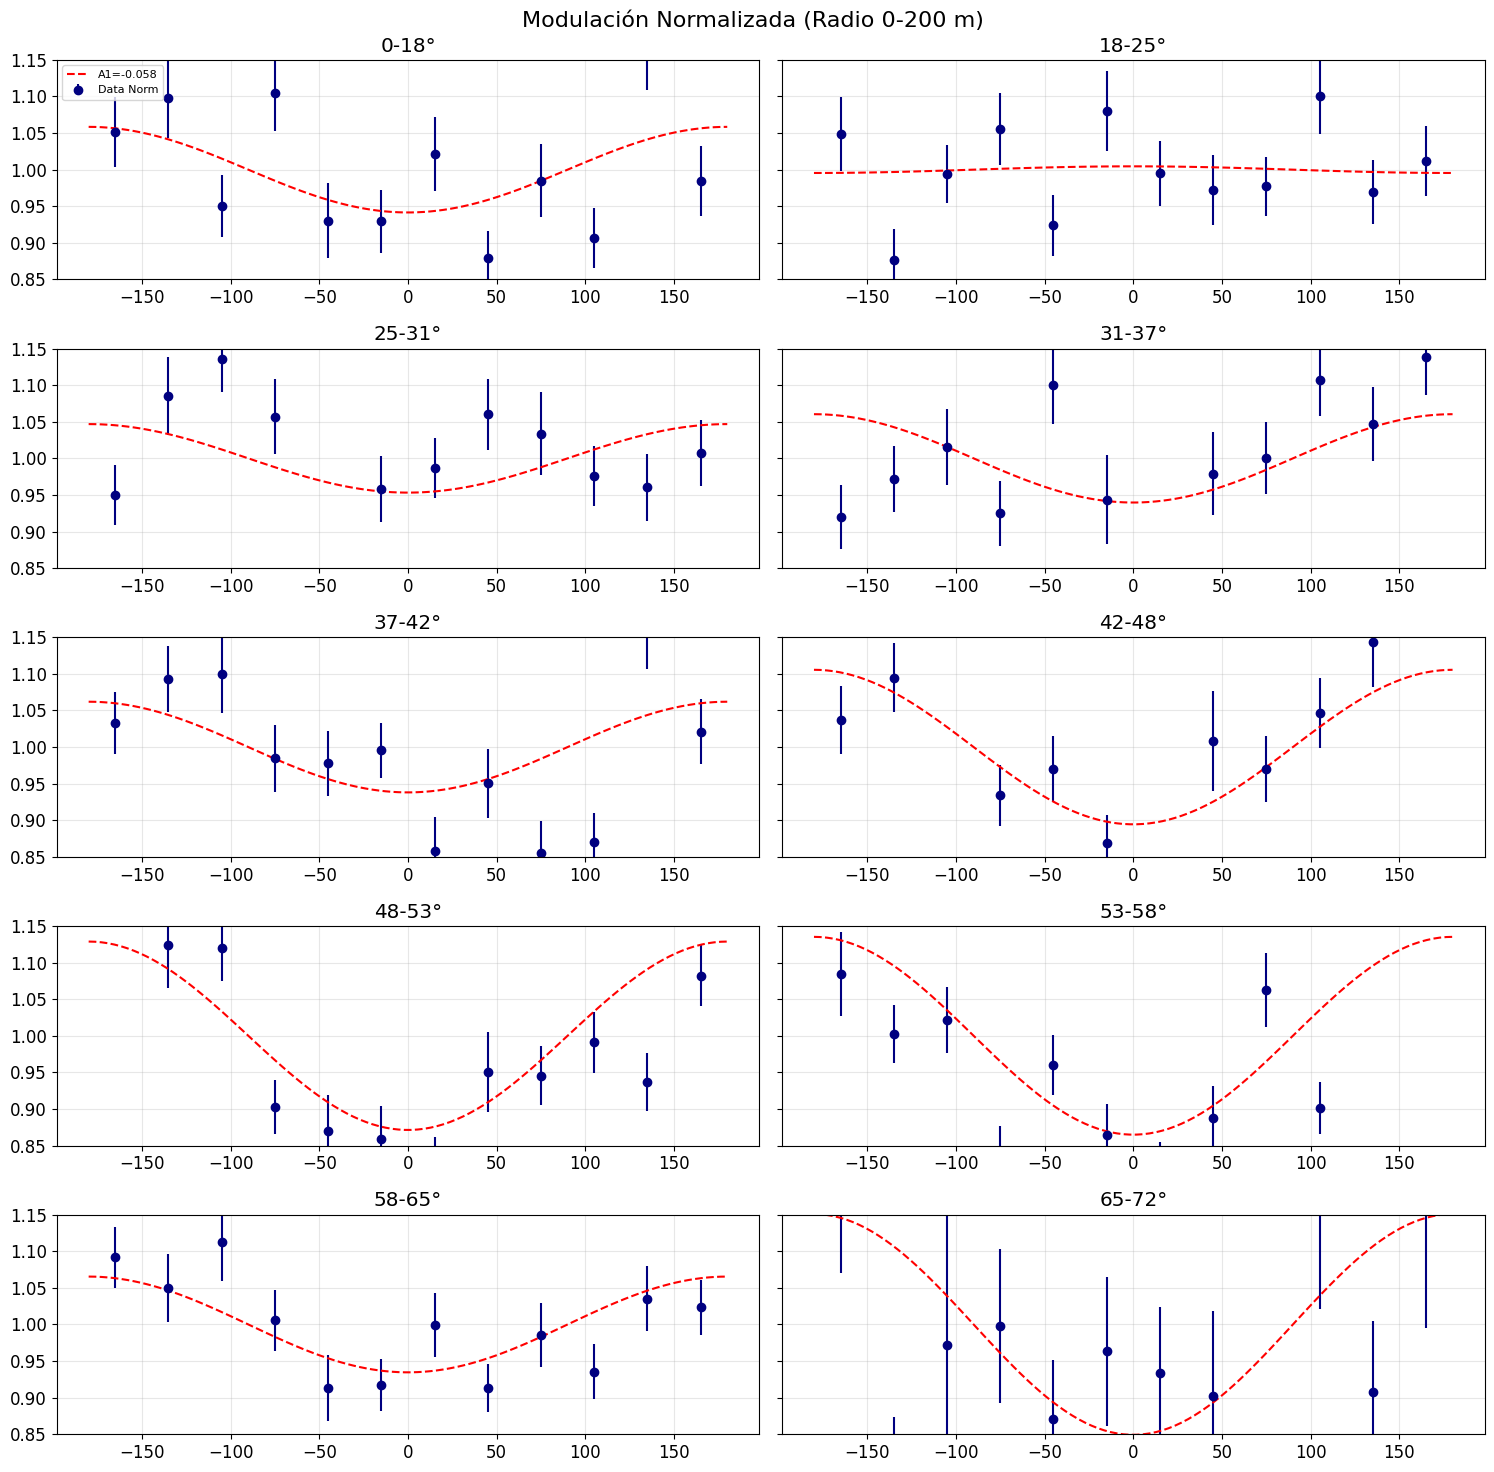

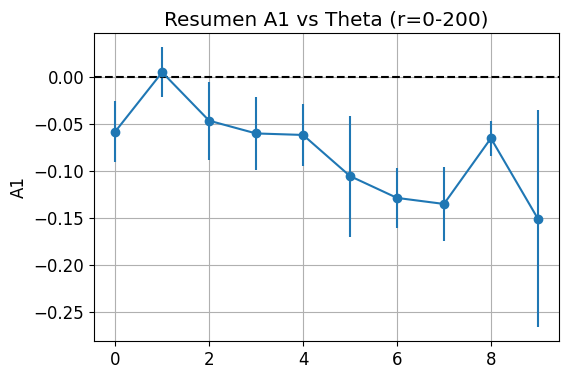

In [88]:
# --- EJEMPLO DE USO ---
# 1. Definí tu carpeta
folder = "/home/lsilva/Github/ADST_Alexey_module_v7/parquet_sib_helio_17/" # Poné la ruta real acá

# 2. Instanciá y cargá
analyzer = RadialCutAnalyzer(folder)
analyzer.load_data()

# 3. ¡Jugá con los cortes! 
analyzer.analizar_corte(r_min=0, r_max=200)   # Cerca
# analyzer.analizar_corte(r_min=600, r_max=1000)  # Medio
# analyzer.analizar_corte(r_min=1000, r_max=2000) # Lejos